# FASE 6: Skenario C (Optimized) - Pengejaran Akurasi >85%
**Proyek Skripsi:** Klasifikasi Jenis Obat Tablet Menggunakan Convolutional Neural Network (CNN)

## Tujuan Notebook Ini:
Meningkatkan akurasi model EfficientNetB0 dengan mengkombinasikan 4 strategi optimasi sekaligus pada dataset statis (28 Train, 6 Val, 6 Test):
1. **Tuning Augmentasi:** Mengurangi distorsi rotasi (15°) dan zoom (10%) untuk menjaga integritas visual obat.
2. **Batch Size Kecil:** Mengubah `BATCH_SIZE = 8` agar *update* bobot lebih sensitif.
3. **Penebalan Classifier:** Menambahkan `Dense(256)` dan `BatchNormalization` pada *classifier head*.
4. **Deep Fine-Tuning:** Membuka 45 lapisan teratas EfficientNet untuk adaptasi yang lebih ekstrim pada fitur spesifik obat.

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')
print("✅ Library terimpor dan siap tempur!")

Mounted at /content/drive
✅ Library terimpor dan siap tempur!


## 1. Konfigurasi Parameter & Augmentasi (Cara 1 & Cara 4)
Implementasi *Batch Size* 8 dan parameter augmentasi yang lebih "sopan" agar bentuk geometris obat tidak terlalu rusak.

In [ ]:
# Path Direktori
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB'
BASELINE_DIR = os.path.join(BASE_DIR, 'data', 'baseline_dataset')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
OUTPUTS_DIR = os.path.join(BASE_DIR, 'outputs', 'scenario_c_optimized')

os.makedirs(OUTPUTS_DIR, exist_ok=True)

TARGET_CLASSES = [
    "cataflam_50_mg", "cetirizin_10_mg", "pantoprazol_sandoz_40_mg",
    "c_vitamin_teva_500_mg", "aspirin_ultra_500_mg",
    "algoflex_forte_dolo_400_mg", "merckformin_xr_1000_mg"
]

IMG_SIZE = (224, 224)
BATCH_SIZE = 8 # OPTIMASI: Batch size diperkecil

# OPTIMASI: Augmentasi lebih halus
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,       # Turun dari 30
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,          # Turun dari 0.2
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

print("Memuat Data Latih (Train)...")
train_generator = train_datagen.flow_from_directory(
    os.path.join(BASELINE_DIR, 'train'), target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', classes=TARGET_CLASSES, shuffle=True
)

print("Memuat Data Validasi (Validation)...")
val_generator = val_test_datagen.flow_from_directory(
    os.path.join(BASELINE_DIR, 'valid'), target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', classes=TARGET_CLASSES, shuffle=False
)

print("Memuat Data Uji (Test)...")
test_generator = val_test_datagen.flow_from_directory(
    os.path.join(BASELINE_DIR, 'test'), target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', classes=TARGET_CLASSES, shuffle=False
)

Memuat Data Latih (Train)...
Found 196 images belonging to 7 classes.
Memuat Data Validasi (Validation)...
Found 42 images belonging to 7 classes.
Memuat Data Uji (Test)...
Found 42 images belonging to 7 classes.


## 2. Arsitektur & Training Tahap 1 (Cara 3: Modifikasi Classifier Head)
Menambahkan lapisan `Dense(256)` dan `BatchNormalization` sebelum output agar proses penarikan kesimpulan lebih mendalam.

In [ ]:
# 1. Build Model dengan Head Baru
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze untuk Tahap 1

x = base_model.output
x = GlobalAveragePooling2D()(x)

# OPTIMASI: Tambahan layer Dense dan BatchNormalization
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

predictions = Dense(len(TARGET_CLASSES), activation='softmax')(x)
model_opt = Model(inputs=base_model.input, outputs=predictions)

model_opt.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# 2. Training Tahap 1 (Warm Up)
MODEL_SAVE_PATH = os.path.join(MODELS_DIR, 'scenario_c_optimized.h5')
checkpoint = ModelCheckpoint(filepath=MODEL_SAVE_PATH, monitor='val_accuracy', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

print("\n🚀 TAHAP 1: Melatih Classifier Head (Warm Up)...")
history_step1 = model_opt.fit(train_generator, epochs=15, validation_data=val_generator, callbacks=[checkpoint, early_stop], verbose=1)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

🚀 TAHAP 1: Melatih Classifier Head (Warm Up)...
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4161 - loss: 1.6653 
Epoch 1: val_accuracy improved from None to 0.61905, saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_c_optimized.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_c_optimized.h5
25/25 ━━━━━━━━━━━━━━━━━━━━ 181s 6s/step - accuracy: 0.5561 - loss: 1.2381 - val_accuracy: 0.6190 - val_loss: 1.2954
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.7318 - loss: 0.6188
Epoch 2: val_accuracy did not improve from 0.61905
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.7551 - loss: 0.5852 - val_accuracy: 0.6190 - val_loss: 0.9957
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8355 - loss: 0.3731
Epoch 3: val_accuracy improved from 0.61905 to 0.71429, saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_c_optimized.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_c_optimized.h5
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 220ms/step - accuracy: 0.8265 - loss: 0.4094 - val_accuracy: 0.7143 - val_loss: 0.8570
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.8440 - loss: 0.3927
Epoch 4: val_accuracy did not improve from 0.71429
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 156ms/step - accuracy: 0.8418 - loss: 0.3823 - val_accuracy: 0.7143 - val_loss: 0.7465
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.8191 - loss: 0.4254
Epoch 5: val_accuracy improved from 0.71429 to 0.78571, saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_c_optimized.h5



Epoch 5: finished saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_c_optimized.h5
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.8367 - loss: 0.4000 - val_accuracy: 0.7857 - val_loss: 0.6417
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.7884 - loss: 0.4187
Epoch 6: val_accuracy did not improve from 0.78571
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.7959 - loss: 0.4271 - val_accuracy: 0.7381 - val_loss: 0.7232
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.8768 - loss: 0.3106
Epoch 7: val_accuracy did not improve from 0.78571
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 190ms/step - accuracy: 0.8469 - loss: 0.3741 - val_accuracy: 0.7143 - val_loss: 0.7259
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.8154 - loss: 0.3639
Epoch 8: val_accuracy improved from 0.78571 to 0.85714, saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_c_optimized.h5



Epoch 8: finished saving model to /content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB/models/scenario_c_optimized.h5
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 166ms/step - accuracy: 0.8265 - loss: 0.3557 - val_accuracy: 0.8571 - val_loss: 0.4879
Epoch 9/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.8228 - loss: 0.4443
Epoch 9: val_accuracy did not improve from 0.85714
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.8265 - loss: 0.4187 - val_accuracy: 0.7143 - val_loss: 0.7097
Epoch 10/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.8487 - loss: 0.3590
Epoch 10: val_accuracy did not improve from 0.85714
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 183ms/step - accuracy: 0.8316 - loss: 0.3673 - val_accuracy: 0.8095 - val_loss: 0.7260
Epoch 11/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.8656 - loss: 0.3192
Epoch 11: val_accuracy did not improve from 0.85714
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 158ms/step - accuracy: 0.8367 - loss: 0.3841 - val_accuracy: 0.7381 - val_loss: 

## 3. Training Tahap 2: Deep Fine-Tuning (Cara 2)
Membuka kunci 45 lapisan teratas (sebelumnya hanya 20). Ini memberikan kebebasan mutlak bagi model untuk memodifikasi konvolusi tingkat tingginya khusus untuk tekstur dan warna obat.

In [ ]:
# OPTIMASI: Unfreeze 45 layer teratas
base_model.trainable = True
for layer in base_model.layers[:-45]:
    layer.trainable = False

# Compile ulang dengan Learning Rate super kecil
model_opt.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

print("\n🚀 TAHAP 2: Deep Fine-Tuning pada 45 Lapisan Teratas...")
history_fine = model_opt.fit(train_generator, epochs=30, validation_data=val_generator, callbacks=[checkpoint, early_stop, lr_scheduler], verbose=1)


🚀 TAHAP 2: Deep Fine-Tuning pada 45 Lapisan Teratas...
Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 852ms/step - accuracy: 0.7051 - loss: 0.7483
Epoch 1: val_accuracy did not improve from 0.85714
25/25 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.6990 - loss: 0.8407 - val_accuracy: 0.7857 - val_loss: 0.5082 - learning_rate: 1.0000e-05
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.7512 - loss: 0.7117
Epoch 2: val_accuracy did not improve from 0.85714
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - accuracy: 0.7347 - loss: 0.7398 - val_accuracy: 0.7619 - val_loss: 0.5749 - learning_rate: 1.0000e-05
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8015 - loss: 0.5869
Epoch 3: val_accuracy did not improve from 0.85714
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 138ms/step - accuracy: 0.7398 - loss: 0.7598 - val_accuracy: 0.7619 - val_loss: 0.6344 - learning_rate: 1.0000e-05
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.8195 - loss: 0.5661
Epoch 4: val_a

## 4. Visualisasi & Evaluasi Akhir
Mari kita buktikan apakah racikan keempat strategi optimasi ini berhasil mendongkrak performa klasifikasi di atas 85%.

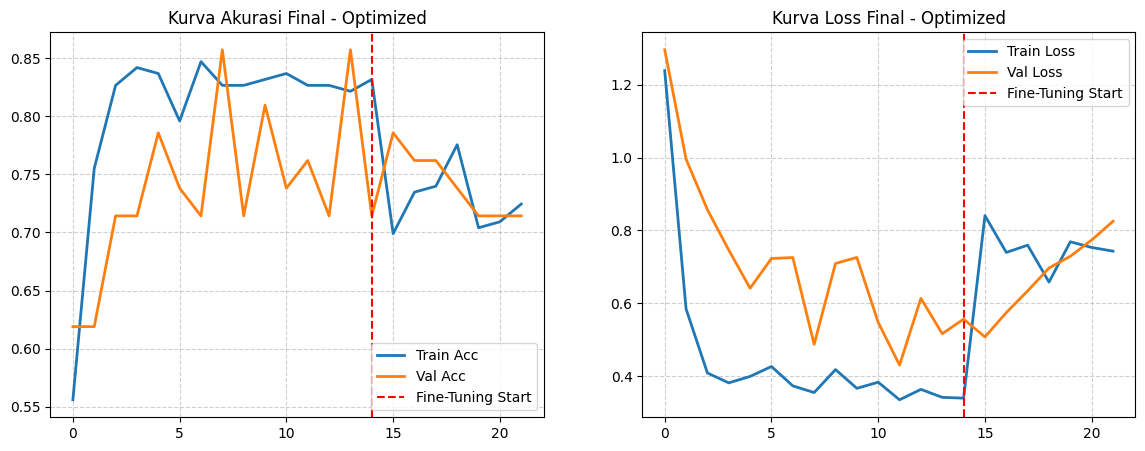


🔍 MENGEVALUASI MODEL OPTIMIZED PADA DATA UJI...


🌟 AKURASI FINAL SKENARIO C (OPTIMIZED) : 80.95% 🌟
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step
                            precision    recall  f1-score   support

            cataflam_50_mg       0.86      1.00      0.92         6
           cetirizin_10_mg       1.00      0.83      0.91         6
  pantoprazol_sandoz_40_mg       0.55      1.00      0.71         6
     c_vitamin_teva_500_mg       0.00      0.00      0.00         6
      aspirin_ultra_500_mg       1.00      0.83      0.91         6
algoflex_forte_dolo_400_mg       1.00      1.00      1.00         6
    merckformin_xr_1000_mg       0.75      1.00      0.86         6

                  accuracy                           0.81        42
                 macro avg       0.74      0.81      0.76        42
              weighted avg       0.74      0.81      0.76        42



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


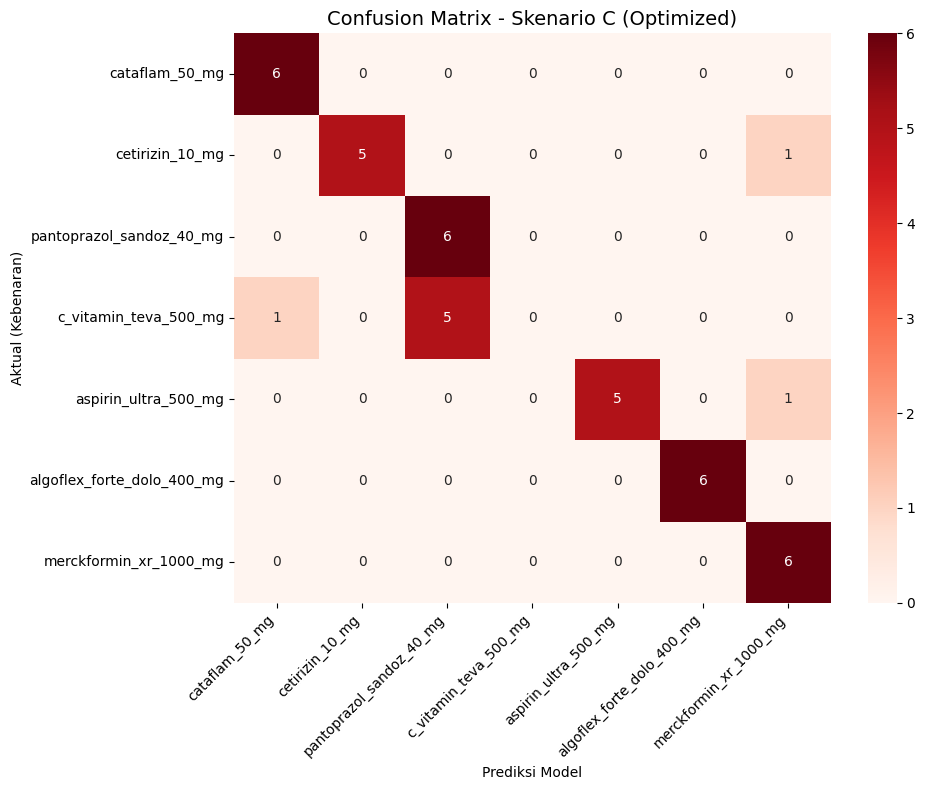

In [ ]:
# 1. Plotting Kurva
acc = history_step1.history['accuracy'] + history_fine.history['accuracy']
val_acc = history_step1.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history_step1.history['loss'] + history_fine.history['loss']
val_loss = history_step1.history['val_loss'] + history_fine.history['val_loss']

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Acc', linewidth=2)
plt.plot(val_acc, label='Val Acc', linewidth=2)
plt.axvline(x=len(history_step1.history['accuracy'])-1, color='red', linestyle='--', label='Fine-Tuning Start')
plt.title('Kurva Akurasi Final - Optimized')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss', linewidth=2)
plt.plot(val_loss, label='Val Loss', linewidth=2)
plt.axvline(x=len(history_step1.history['loss'])-1, color='red', linestyle='--', label='Fine-Tuning Start')
plt.title('Kurva Loss Final - Optimized')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig(os.path.join(OUTPUTS_DIR, 'optimized_learning_curves.png'), dpi=300)
plt.show()

# 2. Testing Pengujian Akhir
print("\n🔍 MENGEVALUASI MODEL OPTIMIZED PADA DATA UJI...")
best_model = tf.keras.models.load_model(MODEL_SAVE_PATH)
test_loss, test_acc = best_model.evaluate(test_generator, verbose=0)

print("="*50)
print(f"🌟 AKURASI FINAL SKENARIO C (OPTIMIZED) : {test_acc * 100:.2f}% 🌟")
print("="*50)

test_generator.reset()
predictions = best_model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

report = classification_report(true_classes, predicted_classes, target_names=TARGET_CLASSES)
print(report)
with open(os.path.join(OUTPUTS_DIR, 'optimized_classification_report.txt'), 'w') as f:
    f.write(report)

# 3. Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(true_classes, predicted_classes), annot=True, fmt='d', cmap='Reds', xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES)
plt.title('Confusion Matrix - Skenario C (Optimized)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Aktual (Kebenaran)')
plt.xlabel('Prediksi Model')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'optimized_confusion_matrix.png'), dpi=300)
plt.show()